In [1]:
# CPSC 3720 Assignment 2 Adrian Todd
# Analyzing AESO Electricity Demand and Price
# AESO data from https://www.aeso.ca/market/market-and-system-reporting/data-requests/hourly-generation-metered-volumes-and-pool-price-and-ail-data-2001-to-july-2025

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #I like the styling of seaborn plots better than matplotlib

# --- Loading Data ---

csv_file = '../aeso_data.csv'
aeso_data = csv_file

# Define the specific columns to load
cols_to_use = ['Date_Begin_Local', 'ACTUAL_AIL', 'ACTUAL_POOL_PRICE']

try:
    # Load the CSV into a DataFrame with only the necessary columns
    df = pd.read_csv(aeso_data, usecols=cols_to_use)
    
except FileNotFoundError:
    print(f"Error: '{aeso_data}' not found.")
    exit()
except ValueError as e:
    print(f"Error: Could not find all required columns. {e}")
    exit()

# --- Preparing Data  ---

# Rename columns
df.rename(columns={
    'Date_Begin_Local': 'datetime_str',
    'ACTUAL_AIL': 'demand',
    'ACTUAL_POOL_PRICE': 'price'
}, inplace=True)

# Remove duplicate datetime entries to account for daylight savings time changes
df.drop_duplicates(subset=['datetime_str'], inplace=True)

# Convert the datetime string to a proper datetime object
df['datetime'] = pd.to_datetime(df['datetime_str'])

# Set the new 'datetime' column as the index
df.set_index('datetime', inplace=True)

# Create a final, clean DataFrame
df_cleaned = df[['demand', 'price']].copy()

# Filter for 2 years of data: 2023 - 2025
start_date = '2023-08-01 0:00'
end_date = '2025-08-01 0:00'
df = df_cleaned.loc[start_date:end_date]

print(f"Data loaded and cleaned. Total rows for 2023 - 2025: {len(df)}")

Data loaded and cleaned. Total rows for 2023 - 2025: 17542


C:\Users\adria\AppData\Local\Temp\ipykernel_592\3388001532.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_7day_avg'] = df['demand'].rolling(window=window_size).mean()
C:\Users\adria\AppData\Local\Temp\ipykernel_592\3388001532.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_7day_avg'] = df['price'].rolling(window=window_size).mean()


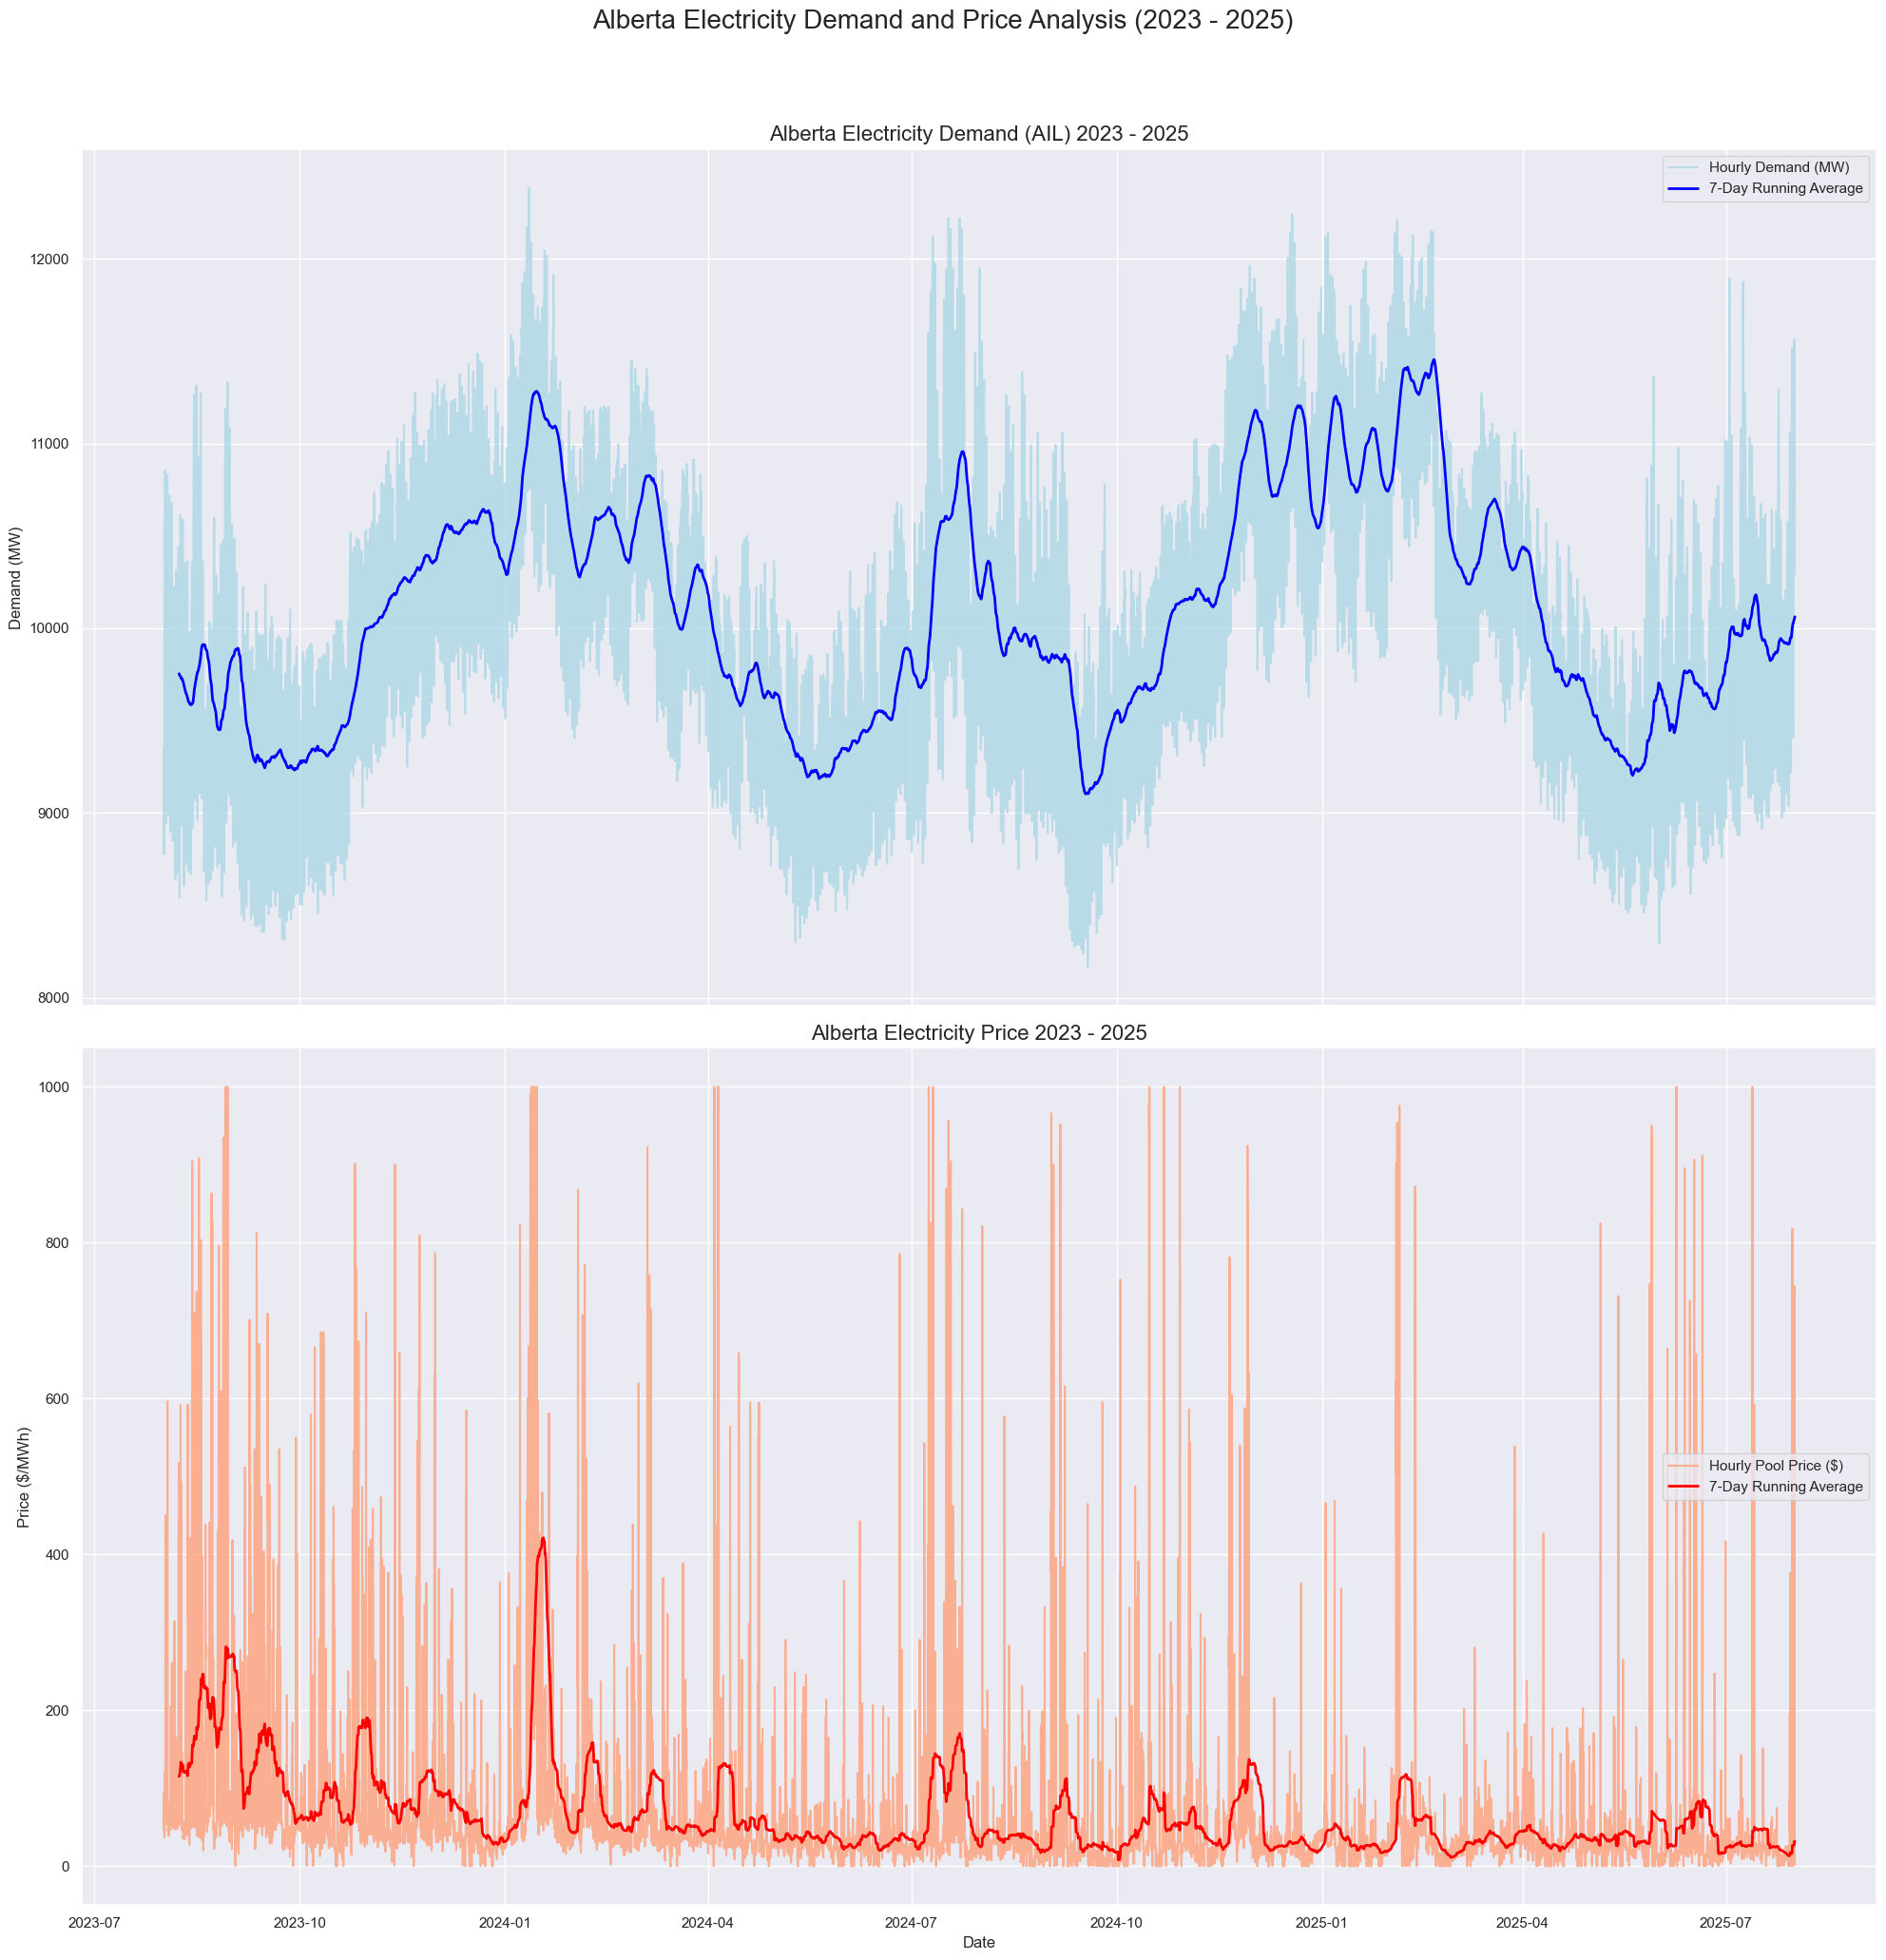

In [ ]:
# --- Data Manipulation ---

# Calculate a 7-day running average
days = 7
hours_per_day = 24
window_size = hours_per_day * days
df['demand_7day_avg'] = df['demand'].rolling(window=window_size).mean()
df['price_7day_avg'] = df['price'].rolling(window=window_size).mean()

# --- Data Visualization  ---

# Stylize plots using Seaborn
sns.set_theme(style="darkgrid")

# Create a figure with two subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(20, 20), 
    sharex=True
)

# --- Electricity Demand Plot ---
ax1.set_title('Alberta Electricity Demand (AIL) 2023 - 2025', fontsize=16)

# Plot raw hourly demand (Series 1)
sns.lineplot(
    data=df, x=df.index, y='demand', 
    label='Hourly Demand (MW)', color='lightblue', alpha=0.8, ax=ax1
)
# Plot 7-day running average of hourly demand (Series 2)
sns.lineplot(
    data=df, x=df.index, y='demand_7day_avg', 
    label='7-Day Running Average', color='blue', linewidth=2, ax=ax1
)


ax1.set_ylabel('Demand (MW)')
ax1.legend()


# --- Electricity Pool Price Plot ---
ax2.set_title('Alberta Electricity Price 2023 - 2025', fontsize=16)

# Plot raw hourly price (Series 3)
sns.lineplot(
    data=df, x=df.index, y='price', 
    label='Hourly Pool Price ($)', color='lightsalmon', alpha=0.8, ax=ax2
)
# Plot 7-day running average of hourly price (Series 4)
sns.lineplot(
    data=df, x=df.index, y='price_7day_avg', 
    label='7-Day Running Average', color='red', linewidth=2, ax=ax2
)

ax2.set_ylabel('Price ($/MWh)')
ax2.set_xlabel('Date')
ax2.legend()

# Set a y-limit for price to make the trend visible
ax2.set_ylim(-50, 1050) 

# --- Save and display Data Visualization ---
plt.suptitle('Alberta Electricity Demand and Price Analysis (2023 - 2025)', fontsize=20, y=1.03)
plt.tight_layout()

# Save the final image
plt.savefig('CPSC3720_Assignment2_AESO_Demand_and_Price_Analysis.png')

# Display plot
plt.show()